In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# TASK 1 : PROBLEM IDENTIFICATION
# ============================================================

print("====================================================")
print("TASK 1 : PROBLEM IDENTIFICATION")
print("====================================================")

print("""

PROBLEM TYPE : IMAGE CLASSIFICATION

WHY?

This dataset contains images divided into 4 folders:

1. normal
2. scratch
3. dent
4. stain

Each image belongs to ONE class only.

Therefore, this is an IMAGE CLASSIFICATION problem.

The objective is to classify manufacturing product
images into their correct defect category using CNN.

""")

TASK 1 : PROBLEM IDENTIFICATION


PROBLEM TYPE : IMAGE CLASSIFICATION

WHY?

This dataset contains images divided into 4 folders:

1. normal
2. scratch
3. dent
4. stain

Each image belongs to ONE class only.

Therefore, this is an IMAGE CLASSIFICATION problem.

The objective is to classify manufacturing product
images into their correct defect category using CNN.




In [3]:
dataset_path = r"D:\bits course\assignment 5\images"

In [4]:
print("====================================================")
print("TASK 2 : DATASET EXPLORATION")
print("====================================================")

TASK 2 : DATASET EXPLORATION


In [5]:
classes = ['normal', 'scratch', 'dent', 'stain']

In [6]:
print("\nNUMBER OF IMAGES PER CLASS\n")

for category in classes:

    folder = os.path.join(dataset_path, category)

    count = len(os.listdir(folder))

    print(f"{category} : {count} images")


NUMBER OF IMAGES PER CLASS

normal : 120 images
scratch : 120 images
dent : 120 images
stain : 120 images


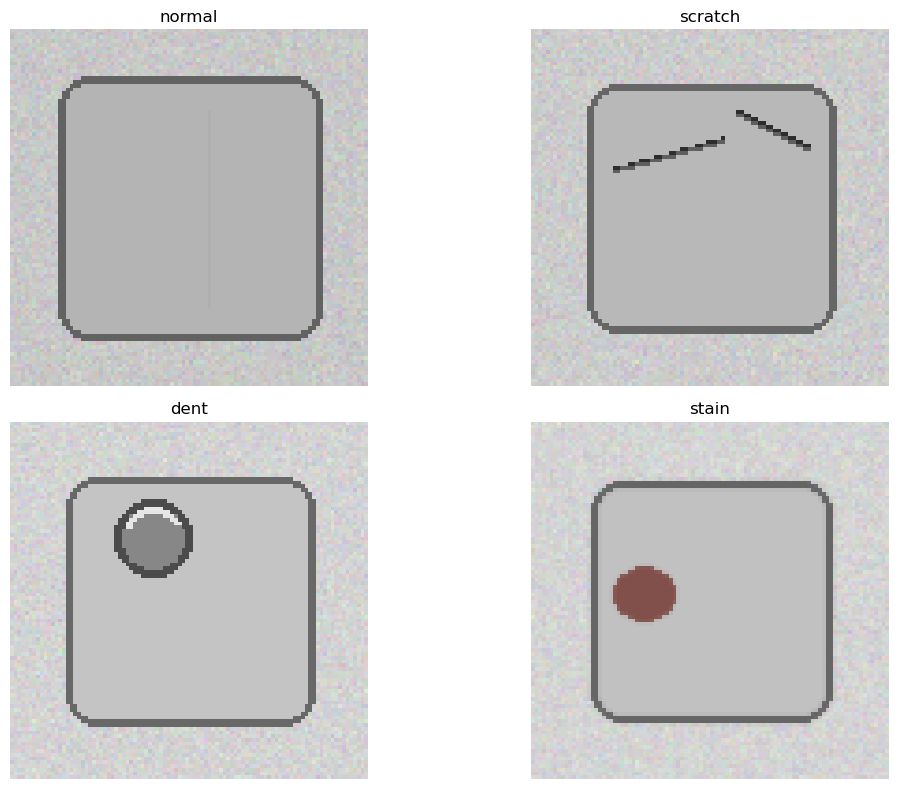

In [7]:

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    folder = os.path.join(dataset_path, category)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(category)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
sample_image_path = os.path.join(
    dataset_path,
    "normal",
    os.listdir(os.path.join(dataset_path, "normal"))[0]
)

sample_image = Image.open(sample_image_path)

print("\nIMAGE DIMENSIONS")

print(sample_image.size)


IMAGE DIMENSIONS
(96, 96)


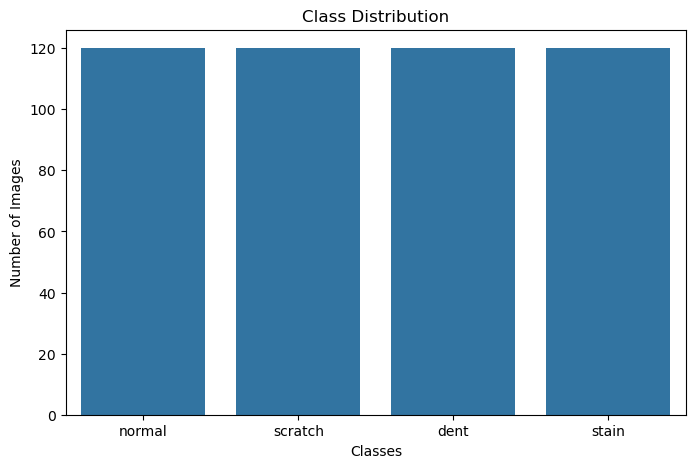

In [9]:
image_counts = []

for category in classes:

    folder = os.path.join(dataset_path, category)

    count = len(os.listdir(folder))

    image_counts.append(count)

plt.figure(figsize=(8,5))

sns.barplot(
    x=classes,
    y=image_counts
)

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

In [10]:
print("====================================================")
print("TASK 3 : IMAGE PREPROCESSING")
print("====================================================")

print("""

PREPROCESSING STEPS:
1. Resize images
2. Normalize pixel values
3. Split into training and validation sets
4. Apply data augmentation

""")

TASK 3 : IMAGE PREPROCESSING


PREPROCESSING STEPS:
1. Resize images
2. Normalize pixel values
3. Split into training and validation sets
4. Apply data augmentation




In [11]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32

In [12]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2
)


In [13]:
train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

Found 384 images belonging to 4 classes.


In [14]:
validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

Found 96 images belonging to 4 classes.


In [15]:
print("\nCLASS LABELS")

print(train_generator.class_indices)


CLASS LABELS
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [16]:
print("====================================================")
print("TASK 4 : CNN MODEL CREATION")
print("====================================================")

print("""

CNN MODEL STRUCTURE:

1. Convolution Layer
2. Activation Function (ReLU)
3. Pooling Layer
4. Flatten Layer
5. Dense Layer
6. Output Layer

""")


TASK 4 : CNN MODEL CREATION


CNN MODEL STRUCTURE:

1. Convolution Layer
2. Activation Function (ReLU)
3. Pooling Layer
4. Flatten Layer
5. Dense Layer
6. Output Layer




In [17]:
model = Sequential()

In [18]:
model.add(

    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation='relu',

        input_shape=(128,128,3)

    )
)

C:\Users\shwet\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.add(

    MaxPooling2D(

        pool_size=(2,2)
    )
)

In [20]:
model.add(

    Conv2D(

        filters=64,

        kernel_size=(3,3),

        activation='relu'
    )
)

In [21]:
model.add(

    MaxPooling2D(

        pool_size=(2,2)
    )
)


In [22]:
model.add(Flatten())

In [23]:
model.add(

    Dense(

        128,

        activation='relu'
    )
)


In [24]:

model.add(

    Dropout(0.5)
)


In [25]:
model.add(

    Dense(

        4,

        activation='softmax'
    )
)

In [26]:
print("\nMODEL SUMMARY\n")

model.summary()


MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [28]:
print("====================================================")
print("TASK 5 : MODEL TRAINING")
print("====================================================")

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10
)


TASK 5 : MODEL TRAINING
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2344 - loss: 2.6502 - val_accuracy: 0.2812 - val_loss: 1.3863
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 490ms/step - accuracy: 0.2734 - loss: 1.3933 - val_accuracy: 0.2500 - val_loss: 1.3862
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 612ms/step - accuracy: 0.2839 - loss: 1.3753 - val_accuracy: 0.2708 - val_loss: 1.3674
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 561ms/step - accuracy: 0.3385 - loss: 1.3514 - val_accuracy: 0.3229 - val_loss: 1.3388
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 545ms/step - accuracy: 0.4688 - loss: 1.2809 - val_accuracy: 0.5417 - val_loss: 1.2013
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 550ms/step - accuracy: 0.5469 - loss: 1.1336 - val_accuracy: 0.6146 - val_loss: 1.0491
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 535ms/step - accuracy: 0.5885 - loss: 1.0188 - val_accuracy: 0.6354 - val_loss: 1.0158
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 549ms/step - accuracy: 0.5859 - loss: 0.9

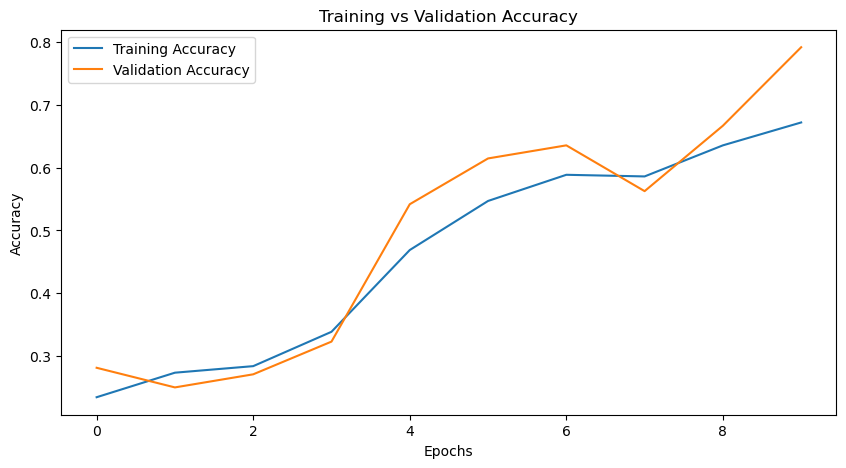

In [29]:
plt.figure(figsize=(10,5))

plt.plot(

    history.history['accuracy'],

    label='Training Accuracy'
)

plt.plot(

    history.history['val_accuracy'],

    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig("accuracy_loss_curves.png")

plt.show()

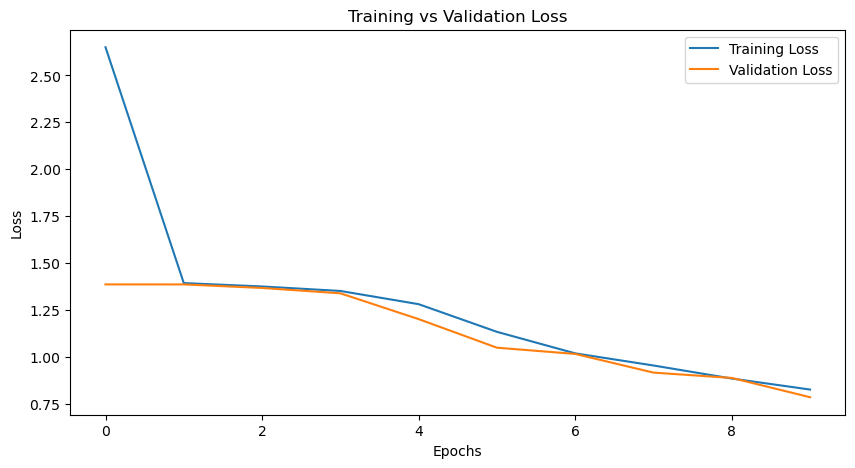

In [30]:

plt.figure(figsize=(10,5))

plt.plot(

    history.history['loss'],

    label='Training Loss'
)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [31]:
print("====================================================")
print("MODEL EVALUATION")
print("====================================================")

validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

MODEL EVALUATION
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step


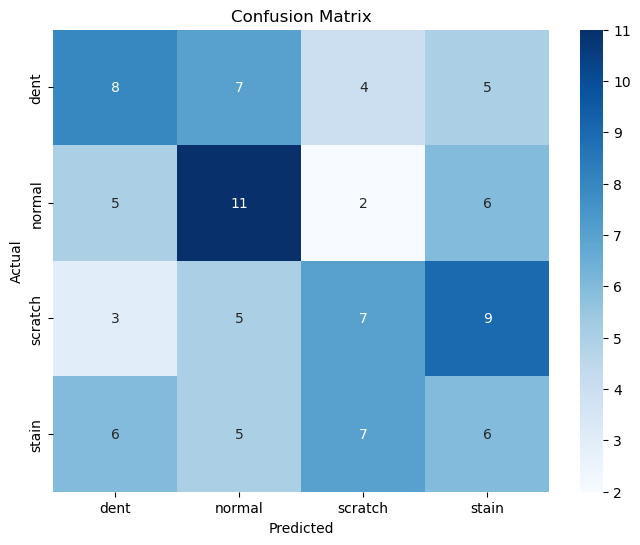

In [32]:
cm = confusion_matrix(

    true_classes,

    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_labels,

    yticklabels=class_labels
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

In [33]:
print("\nCLASSIFICATION REPORT\n")

print(

    classification_report(

        true_classes,

        predicted_classes,

        target_names=class_labels
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        dent       0.36      0.33      0.35        24
      normal       0.39      0.46      0.42        24
     scratch       0.35      0.29      0.32        24
       stain       0.23      0.25      0.24        24

    accuracy                           0.33        96
   macro avg       0.33      0.33      0.33        96
weighted avg       0.33      0.33      0.33        96



SAMPLE PREDICTIONS


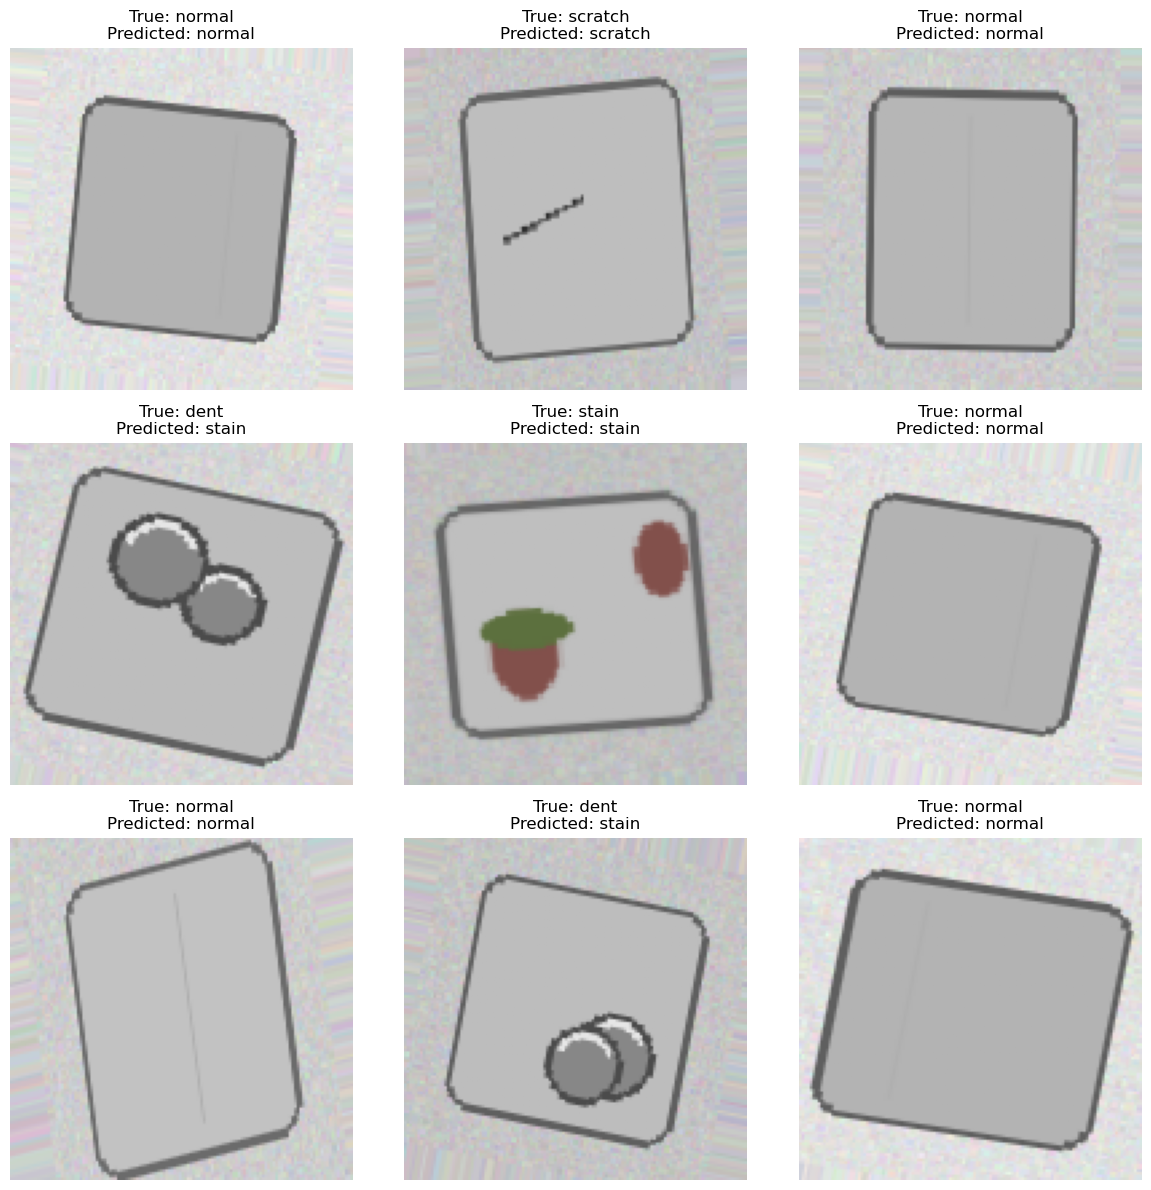

In [36]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

print("====================================================")
print("SAMPLE PREDICTIONS")
print("====================================================")

plt.figure(figsize=(12,12))

for i in range(9):

    image_batch, label_batch = next(validation_generator)

    image = image_batch[0]

    true_label = np.argmax(label_batch[0])

    prediction = model.predict(

        np.expand_dims(image, axis=0),

        verbose=0
    )

    predicted_label = np.argmax(prediction)

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(

        f"True: {class_labels[true_label]}\nPredicted: {class_labels[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()


In [37]:

print("====================================================")
print("TASK 6 : CNN CONCEPT EXPLANATION")
print("====================================================")

print("""

1. WHAT IS CONVOLUTION?
------------------------------------------------
Convolution extracts important image features
such as edges, textures, shapes, and patterns.

CNN filters slide across the image and learn
important visual information automatically.

------------------------------------------------

2. WHY IS POOLING USED?
------------------------------------------------
Pooling reduces image dimensions and computation.

It helps:
- reduce overfitting
- reduce training time
- keep important features

------------------------------------------------

3. WHY IS ReLU COMMONLY USED?
------------------------------------------------
ReLU helps CNN models train faster.

ReLU Formula:
f(x) = max(0, x)

Benefits:
- avoids vanishing gradient problem
- improves learning speed

------------------------------------------------

4. WHY CNN IS BETTER THAN FEED FORWARD NETWORK?
------------------------------------------------
CNN automatically learns image patterns and
spatial relationships.

Feed-forward networks cannot efficiently
understand image structures.

CNNs are specifically designed for image data.

""")

TASK 6 : CNN CONCEPT EXPLANATION


1. WHAT IS CONVOLUTION?
------------------------------------------------
Convolution extracts important image features
such as edges, textures, shapes, and patterns.

CNN filters slide across the image and learn
important visual information automatically.

------------------------------------------------

2. WHY IS POOLING USED?
------------------------------------------------
Pooling reduces image dimensions and computation.

It helps:
- reduce overfitting
- reduce training time
- keep important features

------------------------------------------------

3. WHY IS ReLU COMMONLY USED?
------------------------------------------------
ReLU helps CNN models train faster.

ReLU Formula:
f(x) = max(0, x)

Benefits:
- avoids vanishing gradient problem
- improves learning speed

------------------------------------------------

4. WHY CNN IS BETTER THAN FEED FORWARD NETWORK?
------------------------------------------------
CNN automatically learns image patt

In [38]:
print("====================================================")
print("TASK 7 : BUSINESS USE CASE")
print("====================================================")

print("""

BUSINESS DOMAIN : MANUFACTURING INDUSTRY

USE CASE:
Automatic product quality inspection.

This CNN-based system can:
- detect scratches
- detect dents
- detect stains
- identify defective products automatically

BENEFITS:
- faster quality inspection
- reduced manual work
- reduced human error
- improved manufacturing efficiency
- real-time defect monitoring

""")

TASK 7 : BUSINESS USE CASE


BUSINESS DOMAIN : MANUFACTURING INDUSTRY

USE CASE:
Automatic product quality inspection.

This CNN-based system can:
- detect scratches
- detect dents
- detect stains
- identify defective products automatically

BENEFITS:
- faster quality inspection
- reduced manual work
- reduced human error
- improved manufacturing efficiency
- real-time defect monitoring


